In [2]:
# Importamos librerías básicas
import pandas as pd
import numpy as np
_import random

In [3]:
#Importamos 
import sdv
import sdmetrics

In [4]:
# Importamos sublibrerías para la generación de datos
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [5]:
#Importamos sublibrerias para la evaluación de los datos
from sdmetrics.reports.single_table import QualityReport

In [6]:
print("SDV: ", sdv.__version__)
print("SDMetrics: ", sdmetrics.__version__)

SDV:  1.37.0
SDMetrics:  0.28.0


In [7]:
dfClientes = pd.DataFrame(
    {
        "cliente_id" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "edad" : [17, 18, 19, 25, 32, 42, 70, 28, 23, 22],
        "ingreso_mensual" : [1800, 200, 2500, 15000, 18000, 35000, 7000, 15000, 4000, 5000],
        "ciudad" : ["Potrero Nuevo", "Atoyac", "Cuichapa", "Cordoba", "Cuitlahuac", "Orizaba", "Paraje", "Yanga", "Tierra Blanca", "Calcahualco"]
    }
)

In [8]:
dfClientes

,cliente_id,edad,ingreso_mensual,ciudad
0,1,17,1800,Potrero Nuevo
1,2,18,200,Atoyac
2,3,19,2500,Cuichapa
3,4,25,15000,Cordoba
4,5,32,18000,Cuitlahuac
5,6,42,35000,Orizaba
6,7,70,7000,Paraje
7,8,28,15000,Yanga
8,9,23,4000,Tierra Blanca
9,10,22,5000,Calcahualco


In [9]:
##Obtener los metadata

In [10]:
# Creamos una instancia de SingleTableMetadata
metadata = SingleTableMetadata()

In [11]:
metadata.detect_from_dataframe(
    data = dfClientes
)

In [12]:
metadata.to_dict()

{'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'primary_key': 'cliente_id',
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

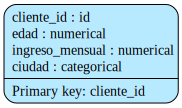

In [26]:
metadata.visualize()

In [18]:
##Entrenar el modelo de datos sinteticos


In [23]:
# Le pasamos los metadatos
synthesizer = GaussianCopulaSynthesizer(
    metadata
)

In [25]:
#Entrenamos el sinteziador con los datos "REALES"
sintetizador.fit(
    dfClientes
)

In [27]:
#Generamos los datos sintéticos
dfClientes_falsos = sintetizador.sample(
    num_rows=200
)

In [29]:
dfClientes_falsos

,cliente_id,edad,ingreso_mensual,ciudad
0,16169768,30,24858,Tierra Blanca
1,4918803,21,1558,Tierra Blanca
2,1900081,21,6670,Orizaba
3,531516,26,1013,Orizaba
4,10211768,41,9833,Tierra Blanca
...,...,...,...,...
195,1577423,18,11223,Cuitlahuac
196,2804584,18,644,Cuichapa
197,10420935,42,4340,Calcahualco
198,16659394,22,3389,Calcahualco


In [32]:
dfClientes_falsos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       200 non-null    int64 
 1   edad             200 non-null    int64 
 2   ingreso_mensual  200 non-null    int64 
 3   ciudad           200 non-null    object
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [33]:
dfClientes.describe()

,cliente_id,edad,ingreso_mensual
count,10.00000,10.000000,10.000000
mean,5.50000,29.600000,10350.000000
std,3.02765,16.063762,10683.866341
min,1.00000,17.000000,200.000000
25%,3.25000,19.750000,2875.000000
50%,5.50000,24.000000,6000.000000
75%,7.75000,31.000000,15000.000000
max,10.00000,70.000000,35000.000000


In [34]:
dfClientes_falsos.describe()

,cliente_id,edad,ingreso_mensual
count,2.000000e+02,200.000000,200.000000
mean,8.765887e+06,26.395000,9248.045000
std,4.707538e+06,13.005178,9196.889172
min,4.660500e+04,18.000000,200.000000
25%,5.085226e+06,18.000000,1826.000000
50%,9.212590e+06,20.000000,5444.000000
75%,1.279456e+07,29.000000,14590.000000
max,1.677377e+07,70.000000,35000.000000


#Evaluamos los datos para validar
1. Parecido entre las columnas (Columns Shapes Score)
2. Parecido entre las relaciones de las columnas (Evaluating Column Per Trends)
3. Evaluar del dataset general

In [36]:
#Evaluamos la calidad de los datos
#Creamos una inslancia de QualityReport
reporte = QualityReport()

#Puntos de referencuia
Score| Interpretación|
-----|---------------|
|1   |Idénticas|
|0.9 | Muy similar|
|0.7 | Similar|
|0.6 | Diferencias visibles|
|<0.5| Muy diferentes|

In [39]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = dfClientes_falsos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 492.35it/s]|
Column Shapes Score: 75.5%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 219.48it/s]|
Column Pair Trends Score: 19.25%

Overall Score (Average): 47.38%

